# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import ttest_ind, norm
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.dgp import RCTs, DataGenerationProcess
import core.rct as rct
from core.variables import *

# DGP

In [29]:
# bernoulli specification
dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(0.1, 0.01), UnivariateGaussian(0.2, std=0.01)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

# continuous specification
# dgp_params = {
#     'n_experiments': 100, 
#     'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
#     'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
#     'dgp_seed': 0
# }

dgp = RCTs(**dgp_params)

In [30]:
samples = dgp.sample(sample_size=5000, seed=0)

# Estimation

In [430]:
emp_te_arr, emp_var_arr = rct.estimate_treatment_effects(samples)

# Selection

In [431]:
selection = rct.select_higher_effect(treatment_effects=emp_te_arr, treatment_vars=emp_var_arr)

# Evaluation

In [432]:
val_est = rct.obj_func(selection=selection, treatment_effects=emp_te_arr)
val_true = rct.obj_func(selection=selection, treatment_effects=dgp.treatment_effects)

result_df = pd.DataFrame({
    'Rank and Select': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Rank and Select
Estimated Policy Value,1.127324
True Policy Value,1.125405
Winner's Curse,0.001918


In [433]:
del dgp, samples, emp_te_arr, selection, val_est, val_true, result_df

# Winner's Curse

In [12]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {}

result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 866 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    2.1s finished


In [13]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.1104 (0.0004)
  - Average Estimated Value: 1.1459 (0.0009)
  - Average Winner's Curse (%): 35.52% (0.90%)


# Estimating Winner's Curse

In [14]:
dgp = RCTs(**dgp_params)
samples = dgp.sample(sample_size=data_params['sample_size'], seed=0)

## Standard Bootstrap

In [15]:
boot_wc_dstn_dict = rct.get_wc_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


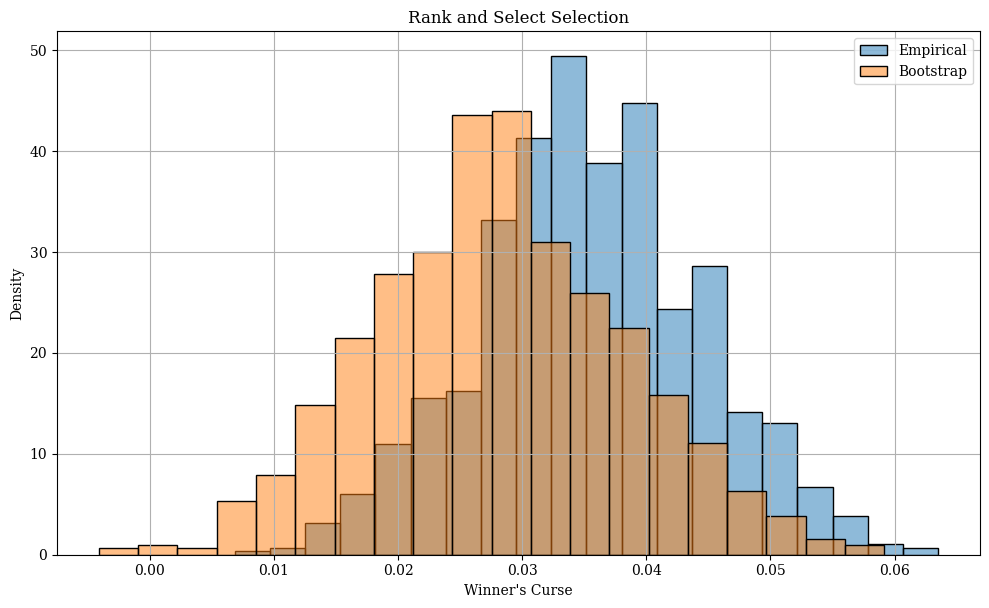

In [16]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [17]:
boot_wc_dstn_dict = rct.get_wc_m_out_of_n_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=0.95, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


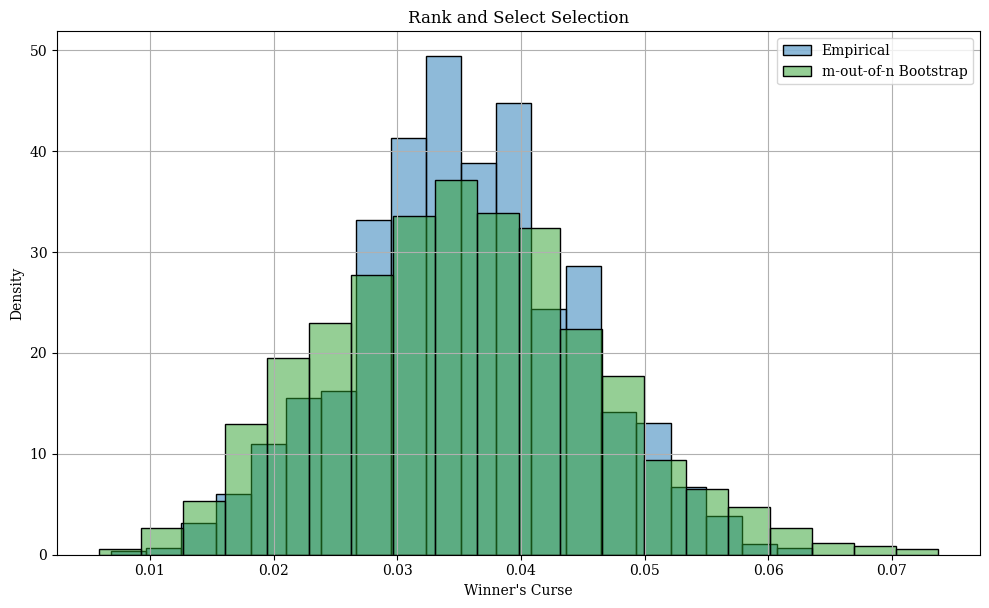

In [18]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [19]:
boot_wc_dstn_dict = rct.get_wc_num_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=-0.45, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


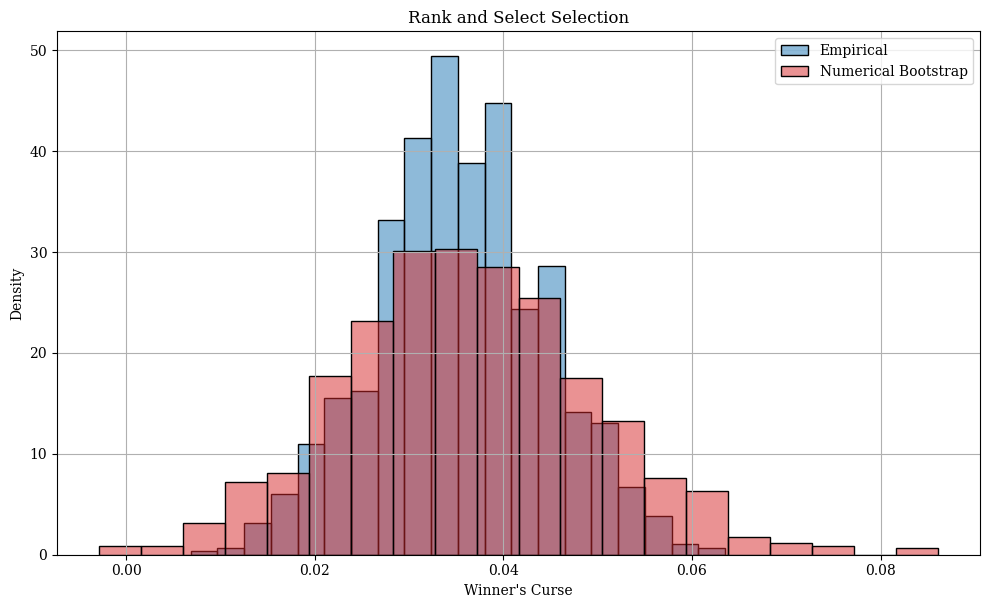

In [20]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [21]:
del dgp, samples, boot_wc_dstn_dict

# Bias Correction

In [12]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [13]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.0min finished



Selection with Rank and Select:
  - True Value: 1.1103 (0.0004)
Winner's Curse: 
  - No Correction: 35.54% (0.88%)
  - Standard Bootstrap: 5.82% (0.96%)
  - m-out-of-n Bootstrap: -0.74% (0.97%)
  - Numerical Bootstrap: -1.88% (0.98%)
  - Bayes (Normal): 24.31% (0.87%)
  - EB (Spike-and-Slab): 13.15% (0.87%)
  - Adj. EB (Spike-and-Slab): -7.85% (2.29%)
Sample Splitting: 
  - True Value: 1.1020 (0.0005)
  - Estimated Value: 1.1017 (0.0015)
  - Winner's Curse (%): -0.30% (1.41%)


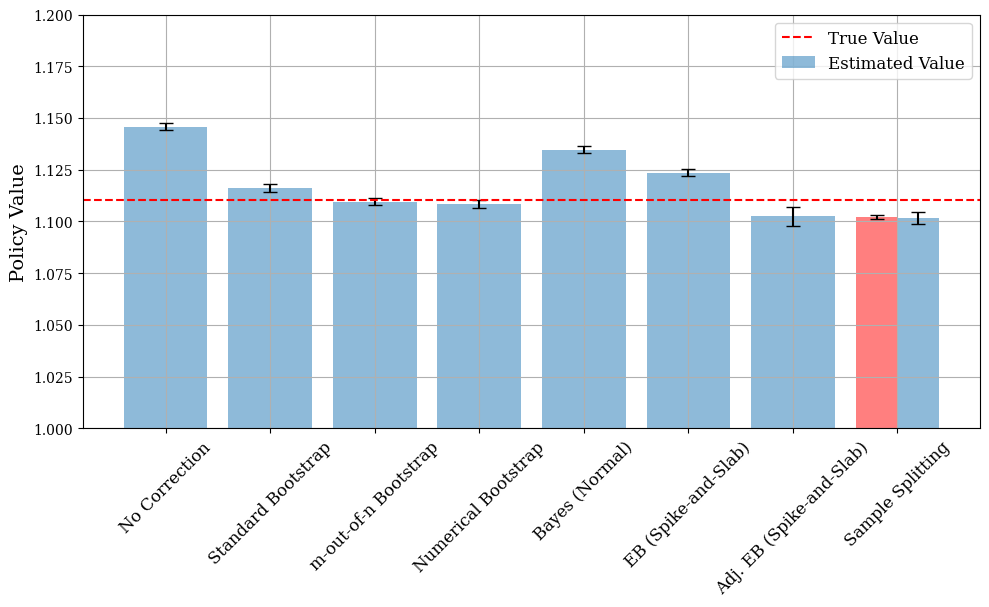

In [14]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

optimizer_key = 'rank_and_select'

wc_dict = {}
val_est_dict = {}

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

for estimator_key in ['nc'] + list(estimators_dict.keys()):
    if estimator_key == 'sample_splitting':
        continue
    
    estimator_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    wc_dict.update({
        estimator_name: {
            "Avg. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_avg'],
            "S.E. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_se'],
        }
    })
    val_est_dict.update({
        estimator_name: {
            "Avg. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_avg'],
            "S.E. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_se'],
        }
    })

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
print(f"Winner's Curse: ")
for estimator_name in wc_dict.keys():
    print(f'  - {estimator_name}: {wc_dict[estimator_name]["Avg. Winners Curse"]/delta_tau:.2%} ({wc_dict[estimator_name]["S.E. Winners Curse"]/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'Sample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(val_est_dict))
bar_values = [val_est_dict[estimator_name]["Avg. Estimated Value"] for estimator_name in val_est_dict.keys()]
bar_errors = [1.95 * val_est_dict[estimator_name]["S.E. Estimated Value"] for estimator_name in val_est_dict.keys()]
    

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
ax.set_xticks(
    np.arange(len(val_est_dict) + 1), 
    labels=list(val_est_dict.keys()) + ['Sample Splitting'], 
    rotation=45, 
    fontsize=tick_label_size
)
ax.set_ylim([1.0, 1.2])
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


# Comparative Statics

## Number of Experiments

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': np.nan, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [16]:
n_tests_list = [10, 25, 50, 75, 100]

num_tests_result_dict = {n_tests: None for n_tests in n_tests_list}

for n_tests in n_tests_list:
    print(f'\nNumber of Experiments = {n_tests}')
    dgp_params['n_experiments'] = n_tests

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    num_tests_result_dict[n_tests] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   36.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   45.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 25
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   32.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 75
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  5.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished


In [17]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

num_tests_wc_avg_df = pd.DataFrame({
    num_tests: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for num_tests, wc_dict in num_tests_result_dict.items()
}).T / delta_tau * 100

num_tests_wc_se_df = pd.DataFrame({
    num_tests: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for num_tests, wc_dict in num_tests_result_dict.items()
}).T / delta_tau * 100

In [18]:
num_tests_wc_avg_df

,nc_wc_avg,sample_splitting_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_spike_slab_wc_avg,eb_spike_slab_adj_wc_avg
10,38.376925,-4.364785,5.776341,-1.171628,-2.541942,26.783315,14.922609,-5.764873
25,42.995880,-0.228715,9.780435,2.814563,1.188661,31.829144,20.086581,-5.159426
50,35.977950,0.369704,6.045016,-0.485512,-1.679282,24.757840,11.364657,-10.643960
75,33.099816,-0.227773,4.852107,-1.519334,-2.434244,21.738932,10.721700,-3.933909
100,35.541411,-0.300165,5.822965,-0.740956,-1.880803,24.311681,13.146945,-7.854716


In [19]:
num_tests_wc_se_df

,nc_wc_se,sample_splitting_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_spike_slab_wc_se,eb_spike_slab_adj_wc_se
10,2.837264,4.402822,3.118672,3.137370,3.207804,2.815677,2.777208,2.859078
25,1.808375,2.795986,1.984806,2.001275,2.044578,1.793758,1.753653,1.819289
50,1.328232,1.971177,1.452152,1.462393,1.480362,1.317135,1.294920,1.337471
75,1.051150,1.621882,1.155731,1.172159,1.190480,1.041965,1.019443,13.519997
100,0.882906,1.412605,0.956694,0.966662,0.976345,0.874677,0.866969,2.291048


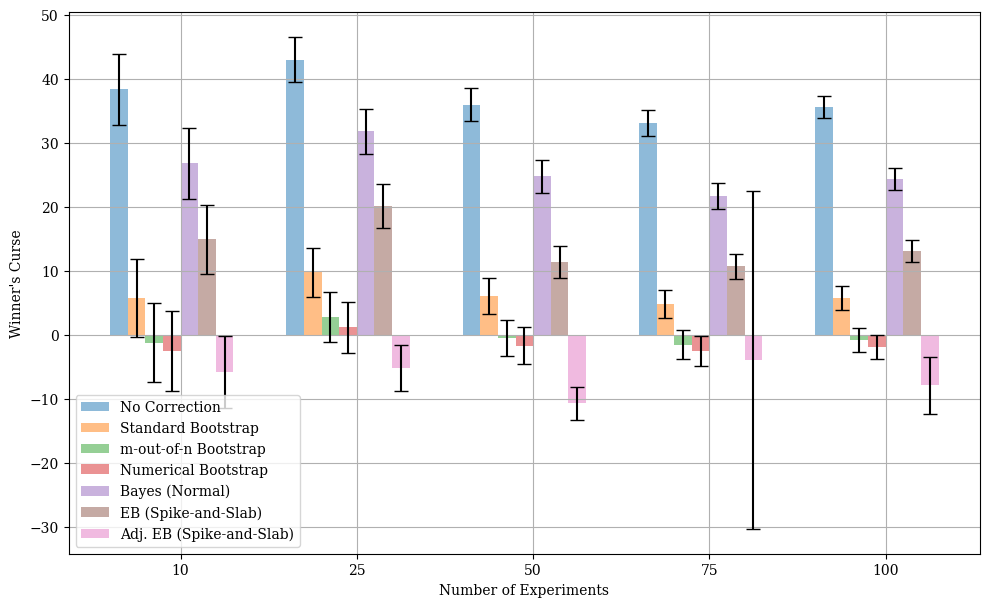

In [ ]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'rank_and_select'

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(num_tests_wc_avg_df.index))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + [item for item in estimators_dict.keys() if item != 'sample_splitting']):

    bar_values = num_tests_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * num_tests_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel('Number of Experiments')
ax.set_ylabel('Winner\'s Curse')
ax.set_xticks(
    np.arange(len(num_tests_wc_avg_df.index)), 
    labels=num_tests_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [45]:
with open('results/ab_test_num_experiments.pkl', 'wb') as f:
    pickle.dump(num_tests_result_dict, f)

## Delta Tau

In [204]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': None,
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

### $\tau_1 = 1.0$

In [ ]:
base_tau = 1.0
delta_tau_list = [0.01, 0.05, 0.1, 0.5]

delta_tau1_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [UnivariateGaussian(base_tau, std=0.1), UnivariateGaussian(base_tau + delta_tau, std=0.1)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau1_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  4.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  6.2min finished


In [ ]:
delta_tau1_wc_avg_df = pd.DataFrame({
delta_tau: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg'] / delta_tau
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for delta_tau, wc_dict in delta_tau1_result_dict.items()
}).T * 100

delta_tau1_wc_se_df = pd.DataFrame({
    delta_tau: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se'] / delta_tau
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for delta_tau, wc_dict in delta_tau1_result_dict.items()
}).T * 100

In [ ]:
delta_tau1_wc_avg_df

,nc_wc_avg,sample_splitting_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_spike_slab_wc_avg,eb_spike_slab_adj_wc_avg
0.01,403.260496,1.824129,79.109368,10.180869,-5.074494,296.326140,147.639800,-86.396858
0.05,78.387611,0.674038,14.966812,1.340228,-1.489819,56.555790,28.910539,-17.761948
0.10,35.541411,-0.300165,5.822965,-0.740956,-1.880803,24.311681,13.146945,-7.854716
0.50,0.230608,-0.225988,-0.546100,-0.882410,-0.746466,-2.725887,0.036161,-0.150224


In [ ]:
delta_tau1_wc_se_df

,nc_wc_se,sample_splitting_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_spike_slab_wc_se,eb_spike_slab_adj_wc_se
0.01,8.810052,14.089860,9.585201,9.670794,9.855235,8.725766,8.563911,25.575277
0.05,1.782777,2.853823,1.931593,1.949001,1.981257,1.766157,1.736488,2.892981
0.10,0.882906,1.412605,0.956694,0.966662,0.976345,0.874677,0.866969,2.291048
0.50,0.200031,0.278301,0.207431,0.210485,0.209648,0.198204,0.200171,0.397067


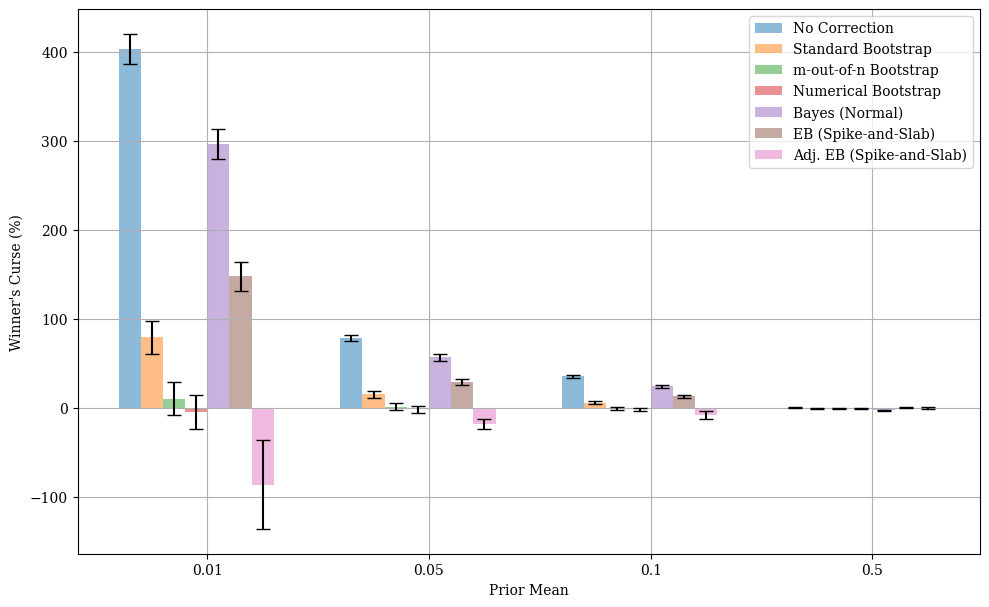

In [ ]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'rank_and_select'

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau1_wc_avg_df.index))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + [item for item in estimators_dict.keys() if item != 'sample_splitting']):
    bar_values = delta_tau1_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * delta_tau1_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )

    # if estimator_key == 'nc':
    #     ax.plot(
    #         bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
    #         bar_values, color=f'C{idx}', linestyle='--', linewidth=2
    #     )

ax.set_xlabel('Prior Mean')
ax.set_ylabel('Winner\'s Curse (%)')
ax.set_xticks(
    np.arange(len(delta_tau1_wc_avg_df.index)), 
    labels=delta_tau1_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [151]:
with open('results/ab_test_delta_tau1.pkl', 'wb') as f:
    pickle.dump(delta_tau1_result_dict, f)

### $\tau_1 = 2.0$

In [205]:
base_tau = 2.0
delta_tau_list = [0.01, 0.05, 0.1, 0.5]

delta_tau2_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [UnivariateGaussian(base_tau, std=0.1), UnivariateGaussian(base_tau + delta_tau, std=0.1)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau2_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  6.4min finished


In [206]:
delta_tau2_wc_avg_df = pd.DataFrame({
delta_tau: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg'] / delta_tau
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for delta_tau, wc_dict in delta_tau2_result_dict.items()
}).T * 100

delta_tau2_wc_se_df = pd.DataFrame({
    delta_tau: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se'] / delta_tau
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for delta_tau, wc_dict in delta_tau2_result_dict.items()
}).T * 100

In [207]:
delta_tau2_wc_avg_df

,nc_wc_avg,sample_splitting_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_spike_slab_wc_avg,eb_spike_slab_adj_wc_avg
0.01,403.260496,1.824129,79.109368,10.180869,-5.074494,198.281761,147.639800,-102.086593
0.05,78.387611,0.674038,14.966812,1.340228,-1.489819,36.943961,28.910539,-20.257705
0.10,35.541411,-0.300165,5.822965,-0.740956,-1.880803,14.510804,13.146945,-8.528631
0.50,0.230608,-0.225988,-0.546100,-0.882410,-0.746466,-4.686349,0.036161,-0.201967


In [208]:
delta_tau2_wc_se_df

,nc_wc_se,sample_splitting_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_spike_slab_wc_se,eb_spike_slab_adj_wc_se
0.01,8.810052,14.089860,9.585201,9.670794,9.855235,8.720633,8.563911,16.133045
0.05,1.782777,2.853823,1.931593,1.949001,1.981257,1.765221,1.736488,2.303825
0.10,0.882906,1.412605,0.956694,0.966662,0.976345,0.874270,0.866969,1.519051
0.50,0.200031,0.278301,0.207431,0.210485,0.209648,0.198311,0.200171,0.205194


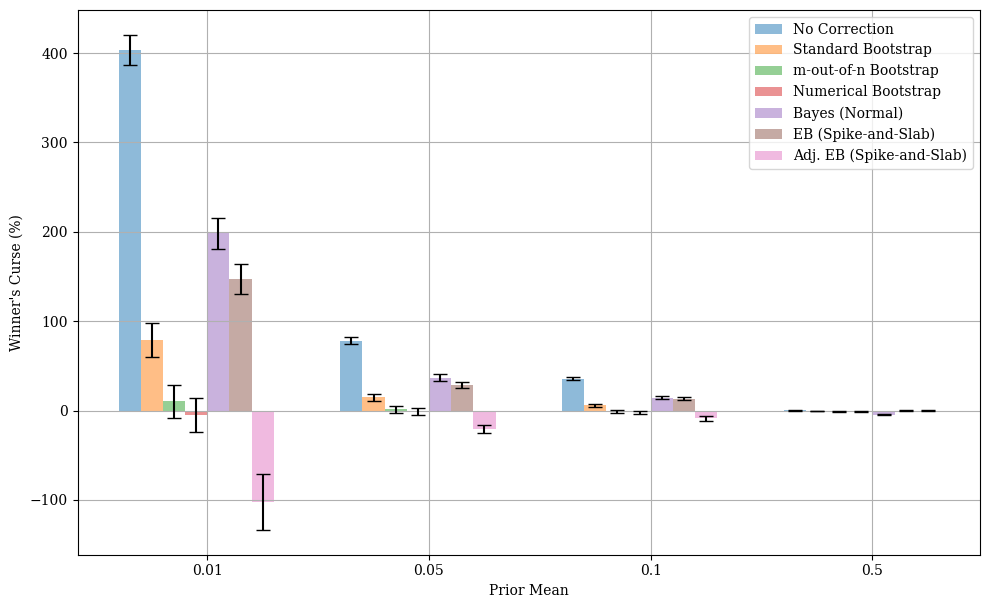

In [209]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'threshold'

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau2_wc_avg_df.index))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + [item for item in estimators_dict.keys() if item != 'sample_splitting']):
    bar_values = delta_tau2_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * delta_tau2_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )

    # if estimator_key == 'nc':
    #     ax.plot(
    #         bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
    #         bar_values, color=f'C{idx}', linestyle='--', linewidth=2
    #     )

ax.set_xlabel('Prior Mean')
ax.set_ylabel('Winner\'s Curse (%)')
ax.set_xticks(
    np.arange(len(delta_tau2_wc_avg_df.index)), 
    labels=delta_tau2_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [210]:
with open('results/ab_test_delta_tau2.pkl', 'wb') as f:
    pickle.dump(delta_tau2_result_dict, f)

## Sample Size

In [89]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [ ]:
sample_size_list = [50, 100, 500, 1000, 2500, 5000]

sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True, truncate_lb=-3.0, truncate_ub=3.0
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  6.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  9.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 13.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 16.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  9.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.3min finished


In [90]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

sample_size_wc_avg_df = pd.DataFrame({
    sample_size: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for sample_size, wc_dict in sample_size_result_dict.items()
}).T / delta_tau * 100

sample_size_wc_se_df = pd.DataFrame({
    sample_size: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for sample_size, wc_dict in sample_size_result_dict.items()
}).T / delta_tau * 100

In [91]:
sample_size_wc_avg_df

,nc_wc_avg,sample_splitting_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_spike_slab_wc_avg,eb_spike_slab_adj_wc_avg
50,60.437408,0.165083,13.366543,5.142280,3.218177,38.079741,25.960850,-5.021243
100,35.541411,-0.300165,5.822965,-0.740956,-1.880803,24.311681,13.146945,-7.854716
500,8.615793,0.259738,0.363366,-2.393148,-2.639624,6.364013,2.110254,-6.192101
1000,4.631887,0.089693,0.264056,-1.462000,-1.549378,3.506233,1.106532,-3.650006
2500,1.909512,0.000507,0.061837,-0.776375,-0.834461,1.459207,0.428946,-1.721346
5000,0.900231,-0.094987,-0.056084,-0.540935,-0.558583,0.675140,0.143961,-1.482310


In [92]:
sample_size_wc_se_df

,nc_wc_se,sample_splitting_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_spike_slab_wc_se,eb_spike_slab_adj_wc_se
50,1.842304,2.817741,2.030248,2.050188,2.082857,1.813645,1.767273,1.811444
100,0.882906,1.412605,0.956694,0.966662,0.976345,0.874677,0.866969,2.291048
500,0.197321,0.285332,0.209965,0.213269,0.215830,0.196975,0.193258,0.218310
1000,0.091627,0.137319,0.095958,0.097018,0.098010,0.091544,0.091170,0.110561
2500,0.039854,0.056764,0.041230,0.041888,0.042333,0.039838,0.039741,0.049830
5000,0.019601,0.027083,0.020038,0.020233,0.020313,0.019597,0.019567,0.032814


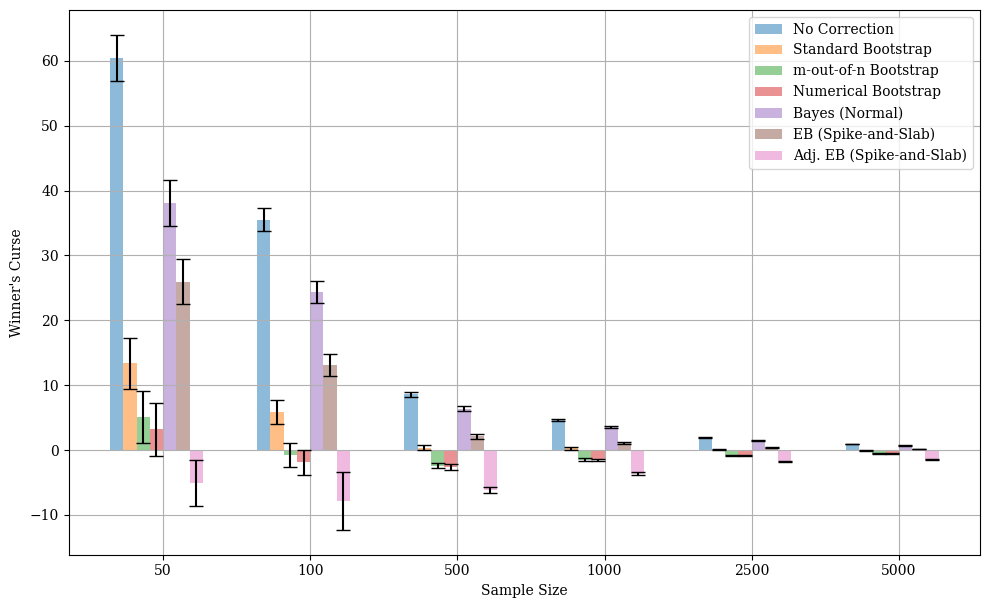

In [ ]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'rank_and_select'

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_wc_avg_df.index))
bar_width = 0.09 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + [item for item in estimators_dict.keys() if item != 'sample_splitting']):
    bar_values = sample_size_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * sample_size_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel('Sample Size')
ax.set_ylabel('Winner\'s Curse')
ax.set_xticks(
    np.arange(len(sample_size_wc_avg_df.index)), 
    labels=sample_size_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [96]:
with open('results/ab_test_sample_size.pkl', 'wb') as f:
    pickle.dump(sample_size_result_dict, f)

## Response STD

In [33]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [34]:
response_std_list = [0.5, 1, 2, 3, 4, 5]

response_std_result_dict = {response_std: None for response_std in response_std_list}

for response_std in response_std_list:
    print(f'\nResponse Standard Deviation = {response_std}')
    
    dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_std), UnivariateGaussian(0, std=response_std)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    response_std_result_dict[response_std] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  8.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  4.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   59.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.3min finished


In [35]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

response_std_wc_avg_df = pd.DataFrame({
    response_std: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for response_std, wc_dict in response_std_result_dict.items()
}).T / delta_tau * 100

response_std_wc_se_df = pd.DataFrame({
    response_std: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for response_std, wc_dict in response_std_result_dict.items()
}).T / delta_tau * 100

In [36]:
response_std_wc_avg_df

,nc_wc_avg,sample_splitting_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_spike_slab_wc_avg,eb_spike_slab_adj_wc_avg
0.5,10.659760,-0.001457,0.825093,-1.571890,-1.727326,7.867452,2.808197,-5.619457
1.0,35.541411,-0.300165,5.822965,-0.740956,-1.880803,24.311681,13.146945,-7.854716
2.0,96.060390,0.143879,23.597957,9.090013,4.828044,50.812120,43.131121,-0.134154
3.0,156.771273,0.651381,42.955964,20.848018,13.487829,55.523959,72.245982,9.948055
4.0,215.881528,-0.046091,61.538801,31.906565,21.572968,39.507038,97.209043,18.238741
5.0,273.842262,0.687467,79.385785,42.229500,28.999242,7.368938,116.800371,24.747414


In [37]:
response_std_wc_se_df

,nc_wc_se,sample_splitting_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_spike_slab_wc_se,eb_spike_slab_adj_wc_se
0.5,0.454444,0.698713,0.480270,0.484933,0.489265,0.453384,0.450360,2.247707
1.0,0.882906,1.412605,0.956694,0.966662,0.976345,0.874677,0.866969,2.291048
2.0,1.676538,2.914547,1.831501,1.847304,1.885973,1.616433,1.610081,1.620905
3.0,2.493527,4.324771,2.723417,2.742578,2.802236,2.304628,2.385876,2.381390
4.0,3.288197,5.701773,3.595209,3.620954,3.702182,2.861440,3.146693,3.112362
5.0,4.095323,7.136476,4.481610,4.512694,4.614591,3.318746,3.921749,3.841613


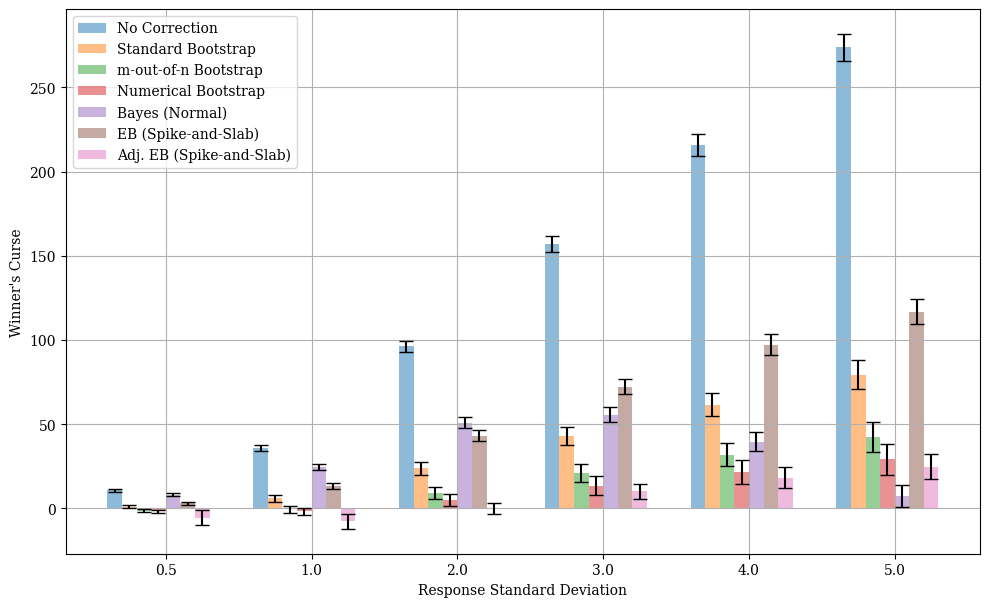

In [ ]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'rank_and_select'

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(response_std_wc_avg_df.index))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + [item for item in estimators_dict.keys() if item != 'sample_splitting']):
    bar_values = response_std_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * response_std_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )


ax.set_xlabel('Response Standard Deviation')
ax.set_ylabel('Winner\'s Curse')
ax.set_xticks(
    np.arange(len(response_std_wc_avg_df.index)), 
    labels=response_std_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [48]:
with open('results/ab_test_response_std.pkl', 'wb') as f:
    pickle.dump(response_std_result_dict, f)

## $\Delta\tau / \sigma$

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': None,
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {}

In [ ]:
ratio_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

response_std_list = [1, 2, 3]

ratio_result_dict = {}

for ratio in ratio_list:
    for response_std in response_std_list:
        delta_tau = response_std * ratio
        print(f'\nRatio = {ratio}; Response Standard Deviation = {response_std}; Delta tau= {delta_tau}')

        dgp_params['base_effects'] = [PointMass(1), PointMass(1 + delta_tau)]
        dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_std), UnivariateGaussian(0, std=response_std)]

        result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=False, 
            n_jobs=-1
        )

        ratio_result_dict[(delta_tau, response_std, ratio)] = rct.calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )

In [188]:
ratio_wc_avg_df = pd.DataFrame([
    {
        'ratio': ratio, 'delta_tau': delta_tau, 'response_std': response_std, 
        **{
            f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg'] / response_std
            for optimizer_key in optimization_params.keys()
            for estimator_key in ['nc'] + list(estimators_dict.keys())
        }
    } for (delta_tau, response_std, ratio), wc_dict in ratio_result_dict.items()
])

ratio_wc_se_df = pd.DataFrame([
    {
        'ratio': ratio, 'delta_tau': delta_tau, 'response_std': response_std, 
        **{
            f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se'] / response_std
            for optimizer_key in optimization_params.keys()
            for estimator_key in ['nc'] + list(estimators_dict.keys())
        }
    } for (delta_tau, response_std, ratio), wc_dict in ratio_result_dict.items()
])

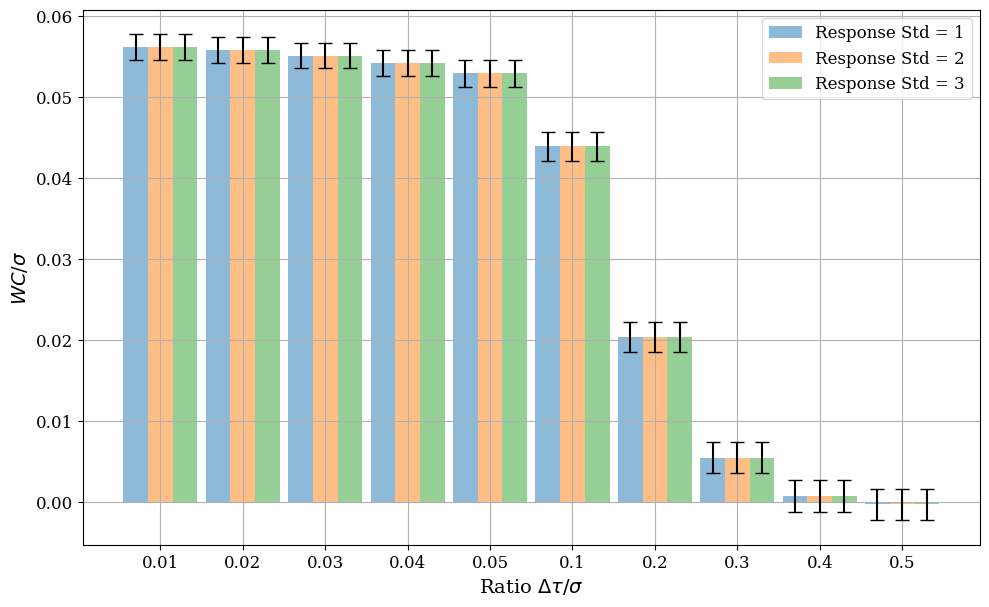

In [203]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
optimizer_key = 'rank_and_select'

bar_positions = np.arange(len(ratio_list))
bar_width = 0.3 * len(response_std_list)

# plot the bars
for idx, response_std in enumerate(response_std_list):
    bar_values = ratio_wc_avg_df[ratio_wc_avg_df['response_std'] == response_std]['nc_wc_avg'].values
    bar_errors = 1.95 * ratio_wc_se_df[ratio_wc_se_df['response_std'] == response_std]['nc_wc_se'].values

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / len(response_std_list) + bar_width / 2 / len(response_std_list),
        bar_values, yerr=bar_errors, capsize=5,
        label=f'Response Std = {response_std}', alpha=0.5, width=bar_width / len(response_std_list)
    )

ax.set_xlabel(r'Ratio $\Delta\tau / \sigma$', fontsize=axis_label_size)
ax.set_ylabel(r'$WC / \sigma$', fontsize=axis_label_size)
ax.set_xticks(
    bar_positions, labels=ratio_list, fontsize=tick_label_size
)
ax.tick_params(axis='y', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()

## Noise distribution

In [11]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [12]:
noise_dstn_dict = {
    'Normal(0, 1)': UnivariateGaussian(0, std=1),
    'Uniform($-\sqrt{3}$, $-\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    'Student T (Dof = 100)': StudentT(100), 
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

noise_dstn_result_dict = {noise_dstn: None for noise_dstn in noise_dstn_dict.keys()}

for noise_key, noise_dstn in noise_dstn_dict.items():
    print(f'\nNoise Distribution = {noise_key}')
    
    dgp_params['noise_vars'] = [noise_dstn, noise_dstn]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    noise_dstn_result_dict[noise_key] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Distribution = Normal(0, 1)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  6.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Uniform($-\sqrt{3}$, $-\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Student T (Dof = 100)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.0min finished


In [13]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

noise_dstn_wc_avg_df = pd.DataFrame({
    noise_key: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for noise_key, wc_dict in noise_dstn_result_dict.items()
}).T / delta_tau * 100

noise_dstn_wc_se_df = pd.DataFrame({
    noise_key: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for noise_key, wc_dict in noise_dstn_result_dict.items()
}).T / delta_tau * 100

In [14]:
for noise_key, noise_dstn in noise_dstn_dict.items():
    print(f'Noise Distribution = {noise_key} has mean = {noise_dstn.mean:.4f} and std = {noise_dstn.std:.4f}')

Noise Distribution = Normal(0, 1) has mean = 0.0000 and std = 1.0000
Noise Distribution = Uniform($-\sqrt{3}$, $-\sqrt{3}$) has mean = 0.0000 and std = 1.0000
Noise Distribution = Student T (Dof = 100) has mean = 0.0000 and std = 1.0102
Noise Distribution = Laplace(0, $1/\sqrt{2}$) has mean = 0.0000 and std = 1.0000
Noise Distribution = Logistic(0, $\sqrt{3} / \pi$) has mean = 0.0000 and std = 1.0000


In [15]:
noise_dstn_wc_avg_df

,nc_wc_avg,sample_splitting_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_spike_slab_wc_avg,eb_spike_slab_adj_wc_avg
"Normal(0, 1)",35.541411,-0.300165,5.822965,-0.740956,-1.880803,24.311681,13.146945,-7.854716
"Uniform($-\sqrt{3}$, $-\sqrt{3}$)",35.250227,-1.007975,5.291705,-1.304955,-2.448460,24.027740,13.109652,-8.519111
Student T (Dof = 100),35.588615,-0.247161,5.342529,-1.266605,-2.474797,24.134248,13.164005,-6.997762
"Laplace(0, $1/\sqrt{2}$)",35.325174,-1.101469,5.686058,-0.843711,-1.988534,24.104824,13.066385,-5.688478
"Logistic(0, $\sqrt{3} / \pi$)",35.268246,-1.069189,5.516844,-1.036194,-2.186768,24.048642,13.061851,-9.000773


In [16]:
noise_dstn_wc_se_df

,nc_wc_se,sample_splitting_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_spike_slab_wc_se,eb_spike_slab_adj_wc_se
"Normal(0, 1)",0.882906,1.412605,0.956694,0.966662,0.976345,0.874677,0.866969,2.291048
"Uniform($-\sqrt{3}$, $-\sqrt{3}$)",0.891837,1.322439,0.962482,0.970372,0.986310,0.884679,0.878594,1.489515
Student T (Dof = 100),0.975377,1.472329,1.061690,1.069475,1.085049,0.966179,0.946400,2.953759
"Laplace(0, $1/\sqrt{2}$)",0.886832,1.369998,0.963913,0.973133,0.989073,0.880079,0.876377,4.593649
"Logistic(0, $\sqrt{3} / \pi$)",0.886760,1.365451,0.963074,0.973023,0.988620,0.880127,0.870820,0.900797


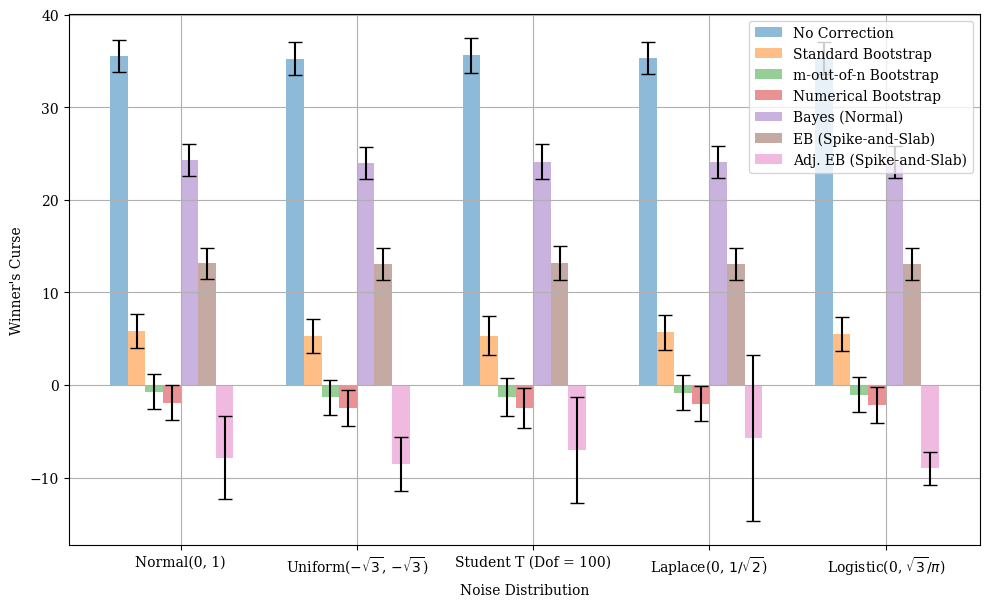

In [17]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'rank_and_select'

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(noise_dstn_wc_avg_df.index))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + [item for item in estimators_dict.keys() if item != 'sample_splitting']):
    bar_values = noise_dstn_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * noise_dstn_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )


ax.set_xlabel('Noise Distribution')
ax.set_ylabel('Winner\'s Curse')
ax.set_xticks(
    np.arange(len(noise_dstn_wc_avg_df.index)), 
    labels=noise_dstn_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# Bernoulli Response

In [6]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': None,
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],  # * Will not be used
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [ ]:
bernoulli_te_list = [
    (0.1, 0.11), (0.2, 0.21), (0.3, 0.31), (0.1, 0.15), (0.2, 0.25), (0.3, 0.35)
]

bernoulli_te_result_dict = {bernoulli_te: None for bernoulli_te in bernoulli_te_list}

for te_tuple in bernoulli_te_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effects'] = [UnivariateGaussian(te_tuple[0], std=0.01), UnivariateGaussian(te_tuple[1], std=0.01)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_te_result_dict[te_tuple] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params, 
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


(tau_1, tau_2)= (0.1, 0.11)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


In [ ]:
bernoulli_te_wc_avg_df = pd.DataFrame({
    te_tuple: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg'] / (te_tuple[1] - te_tuple[0])
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for te_tuple, wc_dict in bernoulli_te_result_dict.items()
}).T * 100

bernoulli_te_wc_se_df = pd.DataFrame({
    te_tuple: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se'] / (te_tuple[1] - te_tuple[0])
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for te_tuple, wc_dict in bernoulli_te_result_dict.items()
}).T * 100

In [ ]:
bernoulli_te_wc_avg_df

,,nc_wc_avg,sample_splitting_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_spike_slab_wc_avg,eb_spike_slab_adj_wc_avg
0.1,0.11,162.813657,-1.017983,45.763321,22.901860,15.371545,161.415258,59.577237,-13.022225
0.2,0.21,220.281251,-1.395669,63.570271,33.298479,23.060755,216.194450,94.849225,2.758019
0.3,0.31,251.430065,-5.432137,70.907241,36.332619,24.211180,244.074348,115.304331,12.492837
0.1,0.15,22.789119,-0.524215,2.616501,-2.206617,-2.628227,22.373711,7.499727,-3.608357
0.2,0.25,34.295923,-0.555974,6.121540,-0.086609,-1.171852,33.306110,14.350656,-0.874038
0.3,0.35,40.844425,-0.984011,7.999785,1.010017,-0.469698,39.195613,18.706059,1.344911


In [ ]:
bernoulli_te_wc_se_df

,,nc_wc_se,sample_splitting_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_spike_slab_wc_se,eb_spike_slab_adj_wc_se
0.1,0.11,2.602325,4.355547,2.803638,2.806313,2.881539,2.597110,2.371151,2.316029
0.2,0.21,3.543588,5.488035,3.808638,3.802659,3.894969,3.533361,3.354845,3.299785
0.3,0.31,3.920761,6.446355,4.219364,4.220585,4.334083,3.908250,3.768027,3.690833
0.1,0.15,0.672431,0.967588,0.724652,0.731724,0.744075,0.671045,0.617411,0.635390
0.2,0.25,0.800914,1.178981,0.863141,0.868235,0.884573,0.798764,0.741406,0.754398
0.3,0.35,0.845132,1.299675,0.915388,0.917545,0.944098,0.842708,0.794461,0.817170


In [ ]:
with open('results/ab_test_bernoulli_delta_tau.pkl', 'wb') as f:
    pickle.dump(bernoulli_te_result_dict, f)

## Sample Size

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(0.1, std=0.01), UnivariateGaussian(0.11, std=0.01)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],  # * Will not be used
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [ ]:
sample_size_list = [50, 100, 500, 1000, 2500, 5000]

bernoulli_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


Sample Size = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  6.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  5.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 500
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  9.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 12.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  6.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 16.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 20.4min finished


In [ ]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

bernoulli_sample_size_wc_avg_df = pd.DataFrame({
    sample_size: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for sample_size, wc_dict in bernoulli_sample_size_result_dict.items()
}).T / delta_tau * 100

bernoulli_sample_size_wc_se_df = pd.DataFrame({
    sample_size: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for sample_size, wc_dict in bernoulli_sample_size_result_dict.items()
}).T / delta_tau * 100

In [ ]:
test = bernoulli_sample_size_result_dict[5000]['rank_and_select_eb_spike_slab_adj_val_est_arr']

valid_idx = test < 0.3 

temp_est_arr = bernoulli_sample_size_result_dict[5000]['rank_and_select_eb_spike_slab_adj_val_est_arr'][valid_idx]
temp_wc_arr = bernoulli_sample_size_result_dict[5000]['rank_and_select_eb_spike_slab_adj_wc_arr'][valid_idx]

bernoulli_sample_size_result_dict[5000]['rank_and_select_eb_spike_slab_adj_val_est_arr'] = temp_est_arr
bernoulli_sample_size_result_dict[5000]['rank_and_select_eb_spike_slab_adj_val_est_avg'] = np.mean(temp_est_arr)
bernoulli_sample_size_result_dict[5000]['rank_and_select_eb_spike_slab_adj_val_est_se'] = np.std(temp_est_arr) / np.sqrt(5000)
bernoulli_sample_size_result_dict[5000]['rank_and_select_eb_spike_slab_adj_wc_arr'] = temp_wc_arr
bernoulli_sample_size_result_dict[5000]['rank_and_select_eb_spike_slab_adj_wc_avg'] = np.mean(temp_wc_arr)
bernoulli_sample_size_result_dict[5000]['rank_and_select_eb_spike_slab_adj_wc_se'] = np.std(temp_wc_arr) / np.sqrt(5000)

In [ ]:
bernoulli_sample_size_wc_avg_df

,nc_wc_avg,sample_splitting_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_spike_slab_wc_avg,eb_spike_slab_adj_wc_avg
50,239.005596,1.526359,74.928780,48.540675,39.383016,235.845710,81.984647,-20.988588
100,162.813657,-1.017983,45.763321,22.901860,15.371545,161.415258,59.577237,-13.022225
500,57.968809,0.740888,11.349716,-2.105154,-5.681393,57.728160,18.191077,-14.358185
1000,33.840376,-0.933232,4.789429,-5.214472,-7.283076,33.723438,8.490617,-14.993161
2500,15.381737,-0.206199,1.165003,-4.865052,-5.620807,15.335843,2.288359,-12.721766
5000,8.198565,-0.535744,0.333547,-3.513301,-3.806549,8.175783,0.777351,-31.318705


In [ ]:
bernoulli_sample_size_wc_se_df

,nc_wc_se,sample_splitting_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_spike_slab_wc_se,eb_spike_slab_adj_wc_se
50,5.497557,8.216948,5.796836,5.827862,5.869832,5.474129,4.928942,4.728996
100,2.602325,4.355547,2.803638,2.806313,2.881539,2.597110,2.371151,2.316029
500,0.578858,0.884629,0.629400,0.632595,0.650047,0.578658,0.549300,0.554503
1000,0.288741,0.454649,0.315212,0.318774,0.329036,0.288688,0.278534,0.312238
2500,0.113178,0.173953,0.122152,0.124065,0.127321,0.113170,0.109153,0.158726
5000,0.058245,0.086903,0.061556,0.062668,0.063844,0.058243,0.057765,0.222145


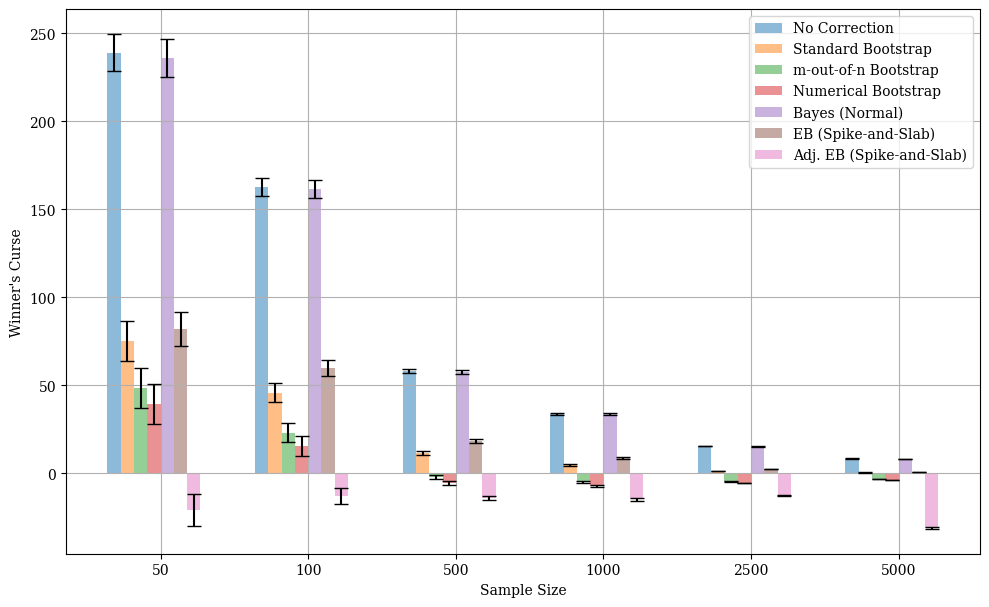

In [ ]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'rank_and_select'

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(bernoulli_sample_size_wc_avg_df.index))
bar_width = 0.09 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + [item for item in estimators_dict.keys() if item != 'sample_splitting']):
    bar_values = bernoulli_sample_size_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * bernoulli_sample_size_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel('Sample Size')
ax.set_ylabel('Winner\'s Curse')
ax.set_xticks(
    np.arange(len(bernoulli_sample_size_wc_avg_df.index)), 
    labels=bernoulli_sample_size_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [ ]:
with open('results/ab_test_bernoulli_sample_size.pkl', 'wb') as f:
    pickle.dump(bernoulli_sample_size_result_dict, f)

# Sketch